## Machine learning Regression

In [1]:
import ten
ten.set_seed(123)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")
import math

## Linear model : Linear regression

In [2]:
data = pd.read_csv("../datasets/carsmall.csv")
data = data.dropna()

In [3]:
n, k = data.shape

In [4]:
data.head()

,Acceleration,Cylinders,Displacement,Horsepower,Weight,MPG
0,12.0,8.0,307.0,130.0,3504.0,18.0
1,11.5,8.0,350.0,165.0,3693.0,15.0
2,11.0,8.0,318.0,150.0,3436.0,18.0
3,12.0,8.0,304.0,150.0,3433.0,16.0
4,10.5,8.0,302.0,140.0,3449.0,17.0


In [5]:
xnp = data[["Weight", "Horsepower", "Acceleration"]].to_numpy()
x = ten.from_numpy(xnp)

In [6]:
ynp = data["MPG"].to_numpy()
y = ten.from_numpy(ynp)

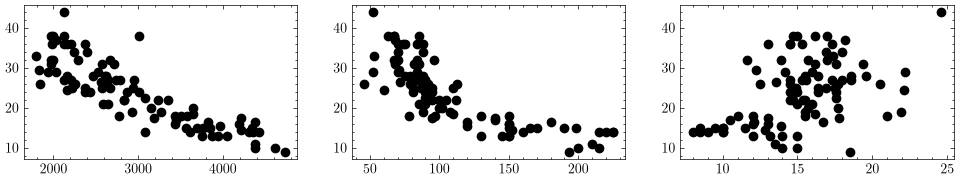

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 2))
for i in range(3):
    axes[i].scatter(xnp[:, i], ynp, color = "black")
plt.show()

**Fit a linear regression model : MPG ~ 1 + Weigth + Horsepower + Acceleration**

In [8]:
model = ten.ml.linear_model(data_type = ten.dtype.float64)

In [9]:
model.fit(x, y)

In [10]:
beta = model.coef()
beta

tensor<float64,4>
47.9768
-0.00654156
-0.0429433
-0.0115827

In [11]:
yhat = model.fitted()
yhat

tensor<float64,93>
19.3335
16.5999
18.9311
18.9391
19.2812
⋮
25.852
31.5253
29.2223
27.1972
26.4377

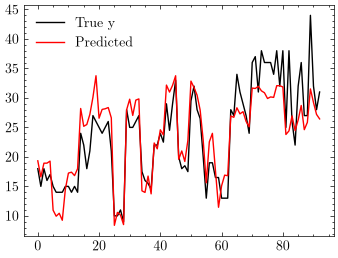

In [12]:
fig, axes = plt.subplots(figsize=(4, 3))
plt.plot(range(n), y, color = "black", label = "True y")
plt.plot(range(n), yhat, color = "red", label = "Predicted")
plt.legend()
plt.show()

**Residuals**

In [13]:
res = y - yhat

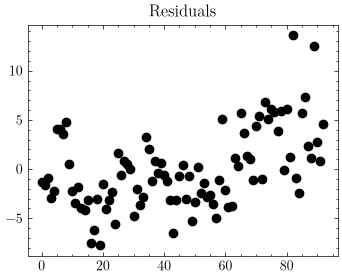

In [14]:
fig, axes = plt.subplots(figsize=(4, 3))
plt.scatter(range(n), res.to_numpy(), color = "black")
plt.title("Residuals")
plt.show()

## Polynomial regression

**Fit polynomial to a trigonometric function**

In [15]:
x = ten.linear(10, 0., 4*math.pi)
y = ten.sin(x)

In [16]:
poly_model = ten.ml.polyreg(8)

In [17]:
poly_model.fit(x, y)

In [18]:
beta = poly_model.coef()
yhat = poly_model.fitted()

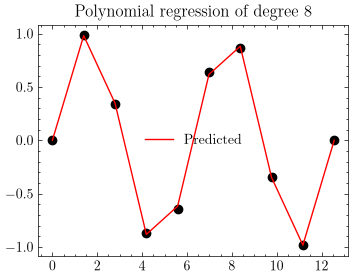

In [19]:
fig, axes = plt.subplots(figsize=(4, 3))
plt.scatter(x.to_numpy(), y.to_numpy(), color = "black")
plt.plot(x, yhat, color = "red", label = "Predicted")
plt.legend()
plt.title("Polynomial regression of degree 8")
plt.show()

**Fit polynomial to a set of points**

In [20]:
x = ten.linear(5, 0., 1.)
y = ten.tensor(5)
for i in range(5):
    y[i] = 1. / (1. + x[i])

In [21]:
poly_model1 = ten.ml.polyreg(5)

In [22]:
poly_model1.fit(x, y)
yhat = poly_model1.fitted()

In [23]:
x1 = ten.linear(10, 0., 2.)
y1 = ten.tensor(10)
for i in range(10):
    y1[i] = 1. / (1. + x1[i])

In [24]:
def poly_eval(model, x):
    beta = model.coef()
    k = beta.size()
    n = x.size()
    xp = ten.tensor((n, k))
    for j in range(n):
        xp[j,0] = 1.
    for i in range(1,k):
        for j in range(n):
            xp[j,i] = xp[j,i-1] * x[j]
    return xp @ beta

In [25]:
yhat1 = poly_eval(poly_model1, x1)

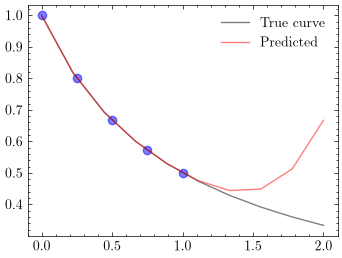

In [26]:
fig, axes = plt.subplots(figsize=(4, 3))
plt.plot(x1, y1, color = "black", label = "True curve", alpha = .5)
plt.plot(x1, yhat1, color = "red", label = "Predicted", alpha = .5)
plt.scatter(x.to_numpy(), y.to_numpy(), color = "blue", alpha = .5)
plt.legend()
plt.show()